In [2]:
# ============================================================
# 1. Imports + Load Data
# ============================================================

import sys, os

while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')

sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed


# Reproducibility
torch.manual_seed(0)
np.random.seed(0)


feed = DataFeed.from_dir(
    "data/egx",
    symbols=["ABUK"]
)

print("Symbols:", feed.symbols)
print("Number of days:", len(feed.dates))

print("Close shape:", feed.close.shape)
print("Returns shape:", feed.returns.shape)

Symbols: ['ABUK']
Number of days: 2857
Close shape: (2857, 1)
Returns shape: (2857, 1)


In [3]:
# ============================================================
# 2. Get ABUK daily returns
# ============================================================

# Because we loaded only ABUK, column 0 is ABUK
returns = feed.returns[:, 0]

print("First 20 returns:")
print(returns[:20])

print("Number of returns:", len(returns))
print("Returns shape:", feed.returns.shape)

First 20 returns:
[ 0.          0.01200003  0.00049412  0.          0.          0.
  0.          0.         -0.00030871 -0.02142632 -0.00290263  0.02518676
  0.         -0.02209884  0.03755847 -0.04654136  0.02252426  0.
  0.         -0.00156013]
Number of returns: 2857
Returns shape: (2857, 1)


In [14]:

# ============================================================
# 3. Create supervised learning data
# ============================================================

LOOKBACK = 20

X = []
y = []
target_dates = []

for t in range(LOOKBACK, len(returns)):

    # Previous 10 returns
    X.append(returns[t-LOOKBACK:t])

    # Next return = target
    y.append(returns[t])

    # Date of the target return
    target_dates.append(feed.dates[t])


X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
target_dates = np.array(target_dates)


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst X:")
print(X[0])

print("\nFirst y:")
print(y[0])

print("\nFirst target date:")
print(target_dates[0])

X shape: (2837, 20)
y shape: (2837,)

First X:
[ 0.          0.01200003  0.00049412  0.          0.          0.
  0.          0.         -0.00030871 -0.02142632 -0.00290263  0.02518676
  0.         -0.02209884  0.03755847 -0.04654136  0.02252426  0.
  0.         -0.00156013]

First y:
0.0

First target date:
2015-02-03 00:00:00


In [15]:
# ============================================================
# 4. Chronological 70/30 split
# ============================================================

split = int(len(X) * 0.70)

X_train_np = X[:split]
y_train_np = y[:split]

X_test_np = X[split:]
y_test_np = y[split:]

dates_train = target_dates[:split]
dates_test = target_dates[split:]


print("Total samples:", len(X))

print("Train samples:", len(X_train_np))
print("Test samples:", len(X_test_np))

print("\nTraining:")
print(dates_train[0], "→", dates_train[-1])

print("\nTesting:")
print(dates_test[0], "→", dates_test[-1])

Total samples: 2837
Train samples: 1985
Test samples: 852

Training:
2015-02-03 00:00:00 → 2023-01-18 00:00:00

Testing:
2023-01-19 00:00:00 → 2026-07-30 00:00:00


In [16]:

# ============================================================
# 5. Prepare data for LSTM
# ============================================================

# MLP input:
# (samples, LOOKBACK)

# LSTM input:
# (samples, LOOKBACK, features)

# We have only one feature:
# daily return

X_train_np = X_train_np.reshape(
    X_train_np.shape[0],
    LOOKBACK,
    1
)

X_test_np = X_test_np.reshape(
    X_test_np.shape[0],
    LOOKBACK,
    1
)


# Convert NumPy arrays to PyTorch tensors

X_train = torch.tensor(X_train_np)
y_train = torch.tensor(y_train_np)

X_test = torch.tensor(X_test_np)
y_test = torch.tensor(y_test_np)


print("\nLSTM input shapes:")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


LSTM input shapes:
X_train shape: torch.Size([1985, 20, 1])
y_train shape: torch.Size([1985])
X_test shape: torch.Size([852, 20, 1])
y_test shape: torch.Size([852])


In [17]:

# ============================================================
# 6. LSTM Model
# ============================================================

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)


    def forward(self, x):

        # x shape:
        # (batch, sequence_length, features)

        lstm_out, (h_n, c_n) = self.lstm(x)

        # Take the output from the last time step
        last_output = lstm_out[:, -1, :]

        # Predict one return
        output = self.fc(last_output)

        return output.squeeze(-1)


model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [18]:

# ============================================================
# 7. Train the LSTM
# ============================================================

EPOCHS = 300
LEARNING_RATE = 0.01

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

train_hist = []
test_hist = []


for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    optimizer.zero_grad()

    train_pred = model(X_train)

    train_loss = nn.functional.mse_loss(
        train_pred,
        y_train
    )

    train_loss.backward()

    optimizer.step()


    # -------------------------
    # Testing
    # -------------------------

    model.eval()

    with torch.no_grad():

        test_pred = model(X_test)

        test_loss = nn.functional.mse_loss(
            test_pred,
            y_test
        )


    # Save losses

    train_hist.append(
        train_loss.detach().item()
    )

    test_hist.append(
        test_loss.detach().item()
    )


print("Number of training loss values:", len(train_hist))
print("Number of testing loss values:", len(test_hist))

print("First 5 train losses:", train_hist[:5])
print("First 5 test losses:", test_hist[:5])

print("Final train loss:", train_hist[-1])
print("Final test loss:", test_hist[-1])


Number of training loss values: 300
Number of testing loss values: 300
First 5 train losses: [0.026851359754800797, 0.006733383983373642, 0.0005362624651752412, 0.003275006776675582, 0.004964989610016346]
First 5 test losses: [0.006933438591659069, 0.0007348698563873768, 0.0034720897674560547, 0.005161715671420097, 0.0037530851550400257]
Final train loss: 0.0004817703738808632
Final test loss: 0.0006821570568718016


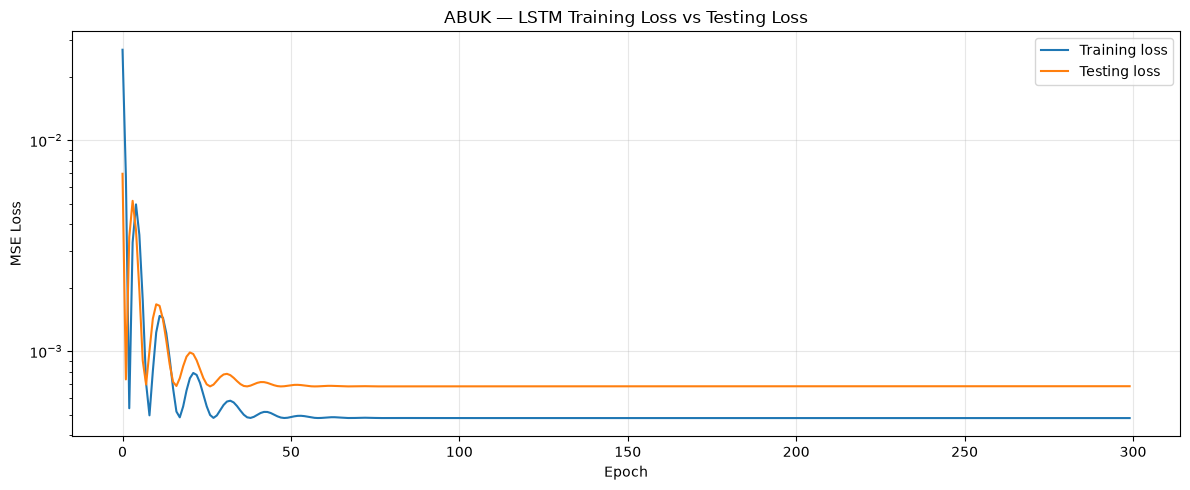

In [19]:

# ============================================================
# 8. Training Loss vs Testing Loss
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    train_hist,
    label="Training loss"
)

plt.plot(
    test_hist,
    label="Testing loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "ABUK — LSTM Training Loss vs Testing Loss"
)

plt.yscale("log")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [20]:

# ============================================================
# 9. Predictions
# ============================================================

model.eval()

with torch.no_grad():

    train_pred = model(X_train).numpy()

    test_pred = model(X_test).numpy()


print("Train predictions:", train_pred.shape)
print("Test predictions:", test_pred.shape)


Train predictions: (1985,)
Test predictions: (852,)


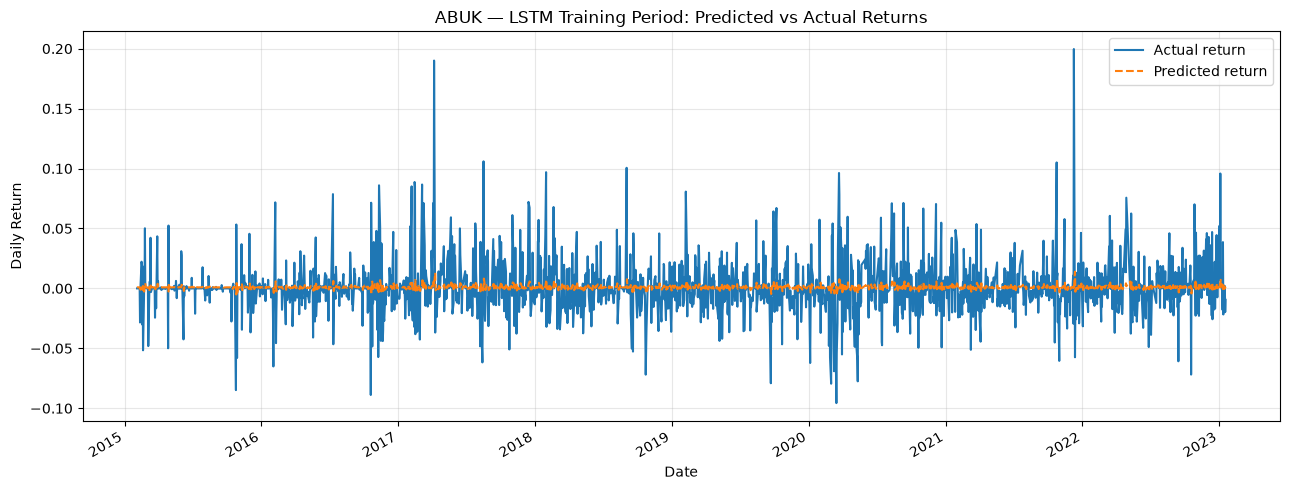

In [21]:
# ============================================================
# 10. Training Period
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_train,
    y_train_np,
    label="Actual return"
)

plt.plot(
    dates_train,
    train_pred,
    label="Predicted return",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.title(
    "ABUK — LSTM Training Period: Predicted vs Actual Returns"
)

plt.grid(alpha=0.3)
plt.legend()

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

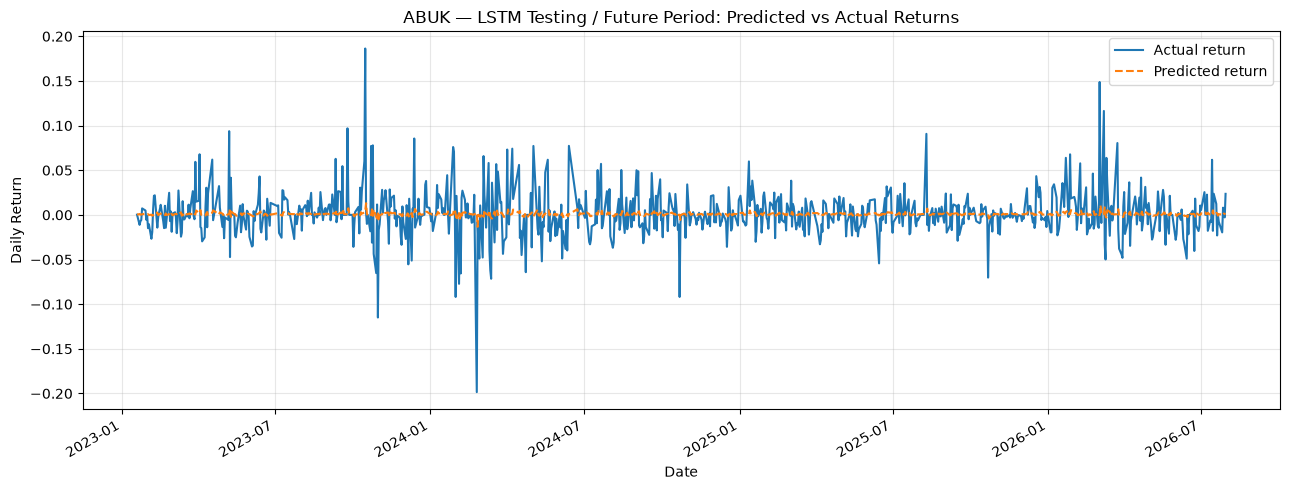

In [22]:

# ============================================================
# 11. Testing / Future Period
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_test,
    y_test_np,
    label="Actual return"
)

plt.plot(
    dates_test,
    test_pred,
    label="Predicted return",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.title(
    "ABUK — LSTM Testing / Future Period: Predicted vs Actual Returns"
)

plt.grid(alpha=0.3)
plt.legend()

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()


In [23]:

# ============================================================
# 12. Final Metrics
# ============================================================

train_mse = np.mean(
    (train_pred - y_train_np) ** 2
)

test_mse = np.mean(
    (test_pred - y_test_np) ** 2
)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)


print(f"Train MSE:  {train_mse:.8f}")
print(f"Test MSE:   {test_mse:.8f}")

print(f"Train RMSE: {train_rmse:.8f}")
print(f"Test RMSE:  {test_rmse:.8f}")

Train MSE:  0.00048177
Test MSE:   0.00068216
Train RMSE: 0.02194926
Test RMSE:  0.02611814
